In [1]:
!pip install pandas numpy matplotlib scikit-learn nltk tensorflow wordcloud gensim seaborn gradio

In [2]:
!pip install -U "huggingface_hub==0.25.2" "gradio==4.44.1" -q

In [3]:
import os
import re
import time
import random
import warnings
import gradio as gr
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except Exception:
    WORDCLOUD_AVAILABLE = False
    print('WordCloud not installed. You can install it using: pip install wordcloud')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [5]:
# To load book review data set 
DATA_PATH = "D:\Download\Book Review Dataset\Book Review Dataset\Book_review.csv"

df = pd.read_csv(DATA_PATH)
print('Dataset loaded successfully.')
print('Shape:', df.shape)
df.head()

Dataset loaded successfully.
Shape: (12000, 4)


,Unnamed: 0,rating,reviewText,summary
0,0,5,This book was the very first bookmobile book I...,50 + years ago...
1,1,1,"When I read the description for this book, I c...",Boring! Boring! Boring!
2,2,5,I just had to edit this review. This book is a...,Wiggleliscious/new toy ready/!!
3,3,5,I don't normally buy 'mystery' novels because ...,Very good read.
4,4,5,"This isn't the kind of book I normally read, a...",Great Story!


In [6]:
#Dataset Understanding and Exploration

print('Columns:', df.columns.tolist())
print('Dataset information:')
df.info()

print('Missing values:')
print(df.isnull().sum())

print('Rating distribution:')
print(df['rating'].value_counts().sort_index())

Columns: ['Unnamed: 0', 'rating', 'reviewText', 'summary']
Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  12000 non-null  int64 
 1   rating      12000 non-null  int64 
 2   reviewText  12000 non-null  object
 3   summary     11998 non-null  object
dtypes: int64(2), object(2)
memory usage: 375.1+ KB
Missing values:
Unnamed: 0    0
rating        0
reviewText    0
summary       2
dtype: int64
Rating distribution:
rating
1    2000
2    2000
3    2000
4    3000
5    3000
Name: count, dtype: int64


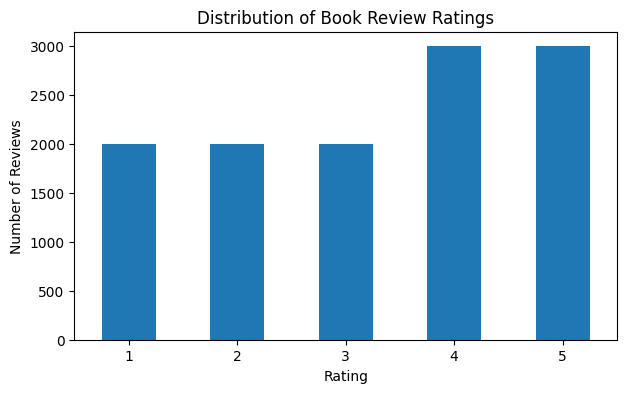

In [7]:
plt.figure(figsize=(7, 4))
df['rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Book Review Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

In [8]:
# Display a few example reviews from each rating class
for rating in sorted(df['rating'].dropna().unique()):
    print("")
    print(f'Rating: {rating}')
    sample_text = df[df['rating'] == rating]['reviewText'].dropna().astype(str).head(1).values
    if len(sample_text) > 0:
        print(sample_text[0][:700], '...')


Rating: 1
When I read the description for this book, I couldn't wait to read it. Once I downloaded it to my Kindle, I found it extremely hard to keep reading it.  To be honest, I stopped reading halfway through the book. It began slow and remained a slow, uninteresting read.  It lacked passion; not making love passion, but passion for life. Neither Jada or Aaron were interesting characters and the story was too, too `everything is perfect'.  Everybody is just so understanding and accommodating--the bit of drama with his father and her grandmother was blah.  To give an example of what I mean (and there are MANY), Aaron finally finds out almost  half way into the book that he fathered a child 5 years ag ...

Rating: 2
This is not a good ghost story, nor is it a romance. To me it was a poorly written Harlequin romance with a lot of smut thrown in.  The author doesn't appear to know what genre` she's trying to capture.There were numerous typos which I found annoying. The author also incor

In [9]:
# Create Text Input and Target Labels

# Keep only needed columns and handle missing values
df = df[['rating', 'summary', 'reviewText']].copy()
df['summary'] = df['summary'].fillna('').astype(str)
df['reviewText'] = df['reviewText'].fillna('').astype(str)

# Combine summary and review text
df['raw_text'] = (df['summary'] + ' ' + df['reviewText']).str.strip()

# Remove rows with missing ratings or empty text
df = df.dropna(subset=['rating'])
df = df[df['raw_text'].str.len() > 0].copy()

# Original classes: 1, 2, 3, 4, 5
# Encoded classes: 0, 1, 2, 3, 4
df['rating'] = df['rating'].astype(int)
df['label'] = df['rating'] - 1

num_classes = df['label'].nunique()
print('Final dataset shape:', df.shape)
print('Number of classes:', num_classes)
print(df[['rating', 'label', 'raw_text']].head())

Final dataset shape: (12000, 5)
Number of classes: 5
   rating  label                                           raw_text
0       5      4  50 + years ago... This book was the very first...
1       1      0  Boring! Boring! Boring! When I read the descri...
2       5      4  Wiggleliscious/new toy ready/!! I just had to ...
3       5      4  Very good read. I don't normally buy 'mystery'...
4       5      4  Great Story! This isn't the kind of book I nor...


In [10]:
# Text Preprocessing

# Basic contraction dictionary for common review phrases
contractions = {
    "can't": "cannot", "won't": "will not", "n't": " not", "i'm": "i am",
    "it's": "it is", "he's": "he is", "she's": "she is", "that's": "that is",
    "what's": "what is", "there's": "there is", "i've": "i have", "we've": "we have",
    "they've": "they have", "i'd": "i would", "you'd": "you would", "i'll": "i will",
    "you'll": "you will", "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "couldn't": "could not", "shouldn't": "should not", "wouldn't": "would not"
}

stop_words = set(stopwords.words('english'))
# Keep negation words because they change meaning strongly in reviews
negation_words = {'no', 'nor', 'not', 'never', 'none', 'cannot'}
stop_words = stop_words - negation_words
lemmatizer = WordNetLemmatizer()

def expand_contractions(text):
    text = str(text).lower()
    for contraction, expanded in contractions.items():
        text = text.replace(contraction, expanded)
    return text

def clean_text(text):
    text = expand_contractions(text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)        # remove URLs
    text = re.sub(r'@\w+', ' ', text)                    # remove mentions
    text = re.sub(r'#', ' ', text)                        # remove hashtag symbol
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)             # remove numbers/special chars
    text = re.sub(r'\s+', ' ', text).strip()             # remove extra spaces
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

# Show before/after cleaning for explanation
sample_indices = df.sample(3, random_state=SEED).index
for idx in sample_indices:
    print("")
    print('BEFORE CLEANING:')
    print(df.loc[idx, 'raw_text'][:600])
    print('\nAFTER CLEANING:')
    print(clean_text(df.loc[idx, 'raw_text'])[:600])


BEFORE CLEANING:
A fun read This book was recommended to me and I actually liked it. If you are looking for suspense this is not your book, it is more like a killing time book where you can figure out what happens next.

AFTER CLEANING:
fun read book recommended actually liked looking suspense not book like killing time book figure happens next

BEFORE CLEANING:
Not so well known to today's readers, but a very old character When I was a child my parents loved these stories - made into several movies - and of course, I thought they were boring and old fashioned.Well, they're still old fashioned, but in a comforting, old world way.  The stories are set in the British Isles for the most part, between WWI and WWII.  Bulldog Drummond makes a habit of saving damsel's in distress with flair and dash.  There's no bad language, course innuendo or explicit sex or violence, just interesting narrative and story lines.  Great for a quiet rainy Sunday.

AFTER CLEANING:
not well known today reader o

In [11]:
start_clean = time.time()
df['clean_text'] = df['raw_text'].apply(clean_text)
cleaning_time = time.time() - start_clean

# Remove rows that became empty after cleaning
df = df[df['clean_text'].str.len() > 0].copy()

print('Cleaning completed in %.2f seconds' % cleaning_time)
print('Shape after cleaning:', df.shape)
df[['rating', 'raw_text', 'clean_text']].head()

Cleaning completed in 4.40 seconds
Shape after cleaning: (12000, 6)


,rating,raw_text,clean_text
0,5,50 + years ago... This book was the very first...,year ago book first bookmobile book bought sch...
1,1,Boring! Boring! Boring! When I read the descri...,boring boring boring read description book cou...
2,5,Wiggleliscious/new toy ready/!! I just had to ...,wiggleliscious new toy ready edit review book ...
3,5,Very good read. I don't normally buy 'mystery'...,good read not normally buy mystery novel not l...
4,5,Great Story! This isn't the kind of book I nor...,great story not kind book normally read althou...


In [12]:
#Visualize Cleaned Text

all_words = ' '.join(df['clean_text']).split()
word_freq = Counter(all_words)
common_words = word_freq.most_common(20)

common_df = pd.DataFrame(common_words, columns=['word', 'frequency'])
common_df

,word,frequency
0,not,19851
1,book,16616
2,story,12355
3,read,9246
4,one,6392
5,character,5943
6,like,5424
7,good,5423
8,would,5054
9,love,4230


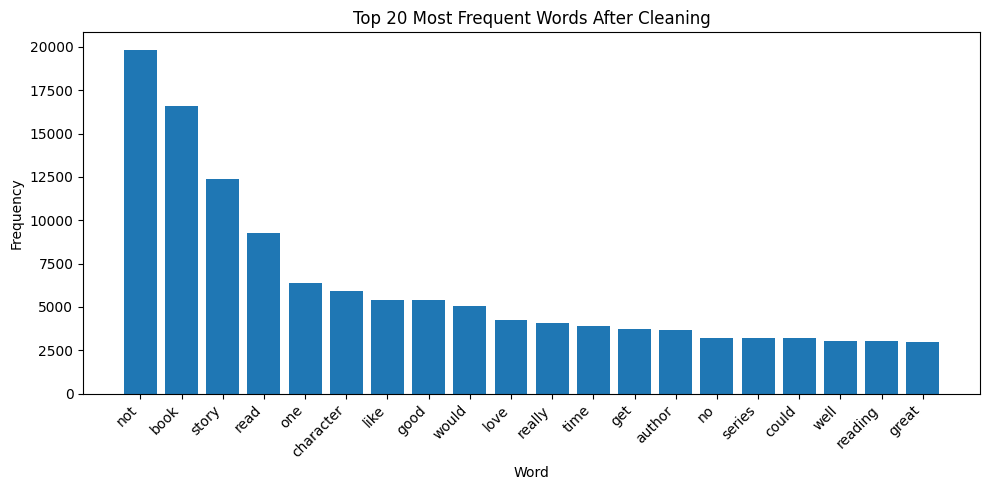

In [13]:
plt.figure(figsize=(10, 5))
plt.bar(common_df['word'], common_df['frequency'])
plt.title('Top 20 Most Frequent Words After Cleaning')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

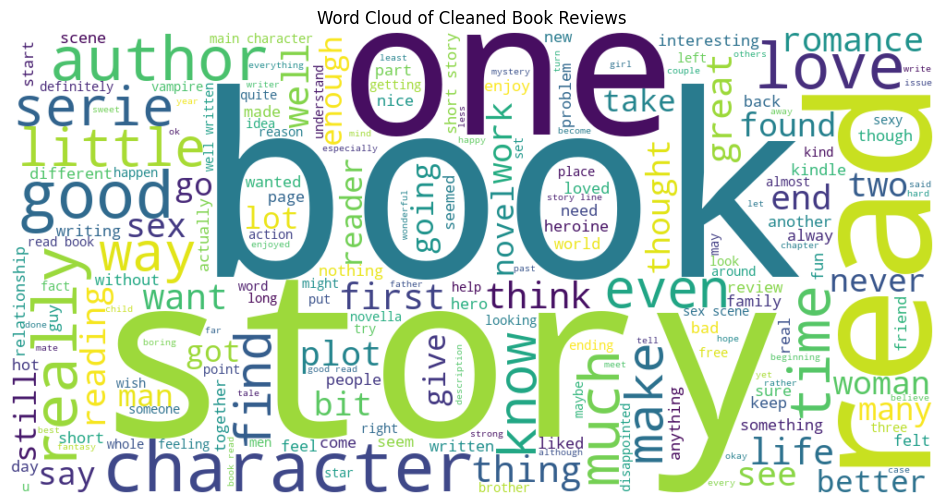

In [14]:
if WORDCLOUD_AVAILABLE:
    text_for_cloud = ' '.join(df['clean_text'].sample(min(3000, len(df)), random_state=SEED))
    wc = WordCloud(width=1000, height=500, background_color='white').generate(text_for_cloud)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Cleaned Book Reviews')
    plt.show()
else:
    print('WordCloud is not available.')

In [15]:
# Train, Validation, and Test Split

X = df['clean_text'].values
y = df['label'].values

# 80-20 train-test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# 0.1 validation split taken from the training portion
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.10,
    random_state=SEED,
    stratify=y_train_full
)

print('Training samples:', len(X_train))
print('Validation samples:', len(X_val))
print('Test samples:', len(X_test))

split_dist = pd.DataFrame({
    'train': pd.Series(y_train).value_counts().sort_index(),
    'validation': pd.Series(y_val).value_counts().sort_index(),
    'test': pd.Series(y_test).value_counts().sort_index()
})
split_dist.index = split_dist.index + 1
split_dist.index.name = 'rating'
split_dist

Training samples: 8640
Validation samples: 960
Test samples: 2400


,train,validation,test
rating,,,
1,1440,160,400
2,1440,160,400
3,1440,160,400
4,2160,240,600
5,2160,240,600


In [16]:
#Tokenization and Percentile-Based Padding

MAX_WORDS = 20000     # maximum vocabulary size
OOV_TOKEN = '<OOV>'   # token for unseen words

# Fit tokenizer only on training data to avoid test-data leakage
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)

train_sequences = tokenizer.texts_to_sequences(X_train)
val_sequences = tokenizer.texts_to_sequences(X_val)
test_sequences = tokenizer.texts_to_sequences(X_test)

lengths = [len(seq) for seq in train_sequences]
MAX_LEN = int(np.percentile(lengths, 95))
MAX_LEN = max(MAX_LEN, 20)

print('95th percentile sequence length:', MAX_LEN)
print('Maximum training sequence length:', max(lengths))
print('Average training sequence length:', np.mean(lengths))

X_train_pad = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(val_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
print('Vocabulary size used:', vocab_size)
print('Padded training shape:', X_train_pad.shape)

95th percentile sequence length: 190
Maximum training sequence length: 1136
Average training sequence length: 57.74027777777778
Vocabulary size used: 20000
Padded training shape: (8640, 190)


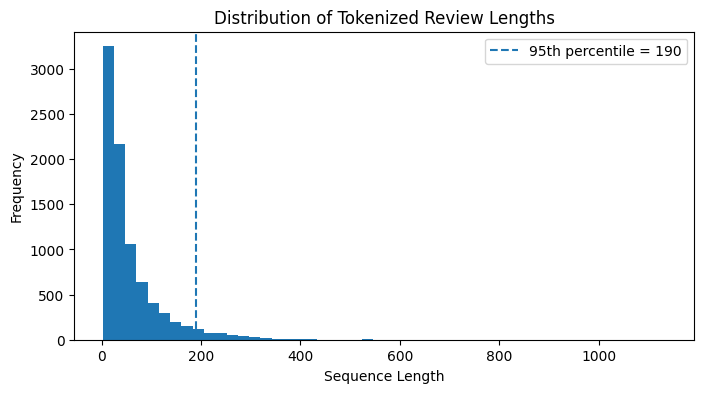

In [17]:
plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=50)
plt.axvline(MAX_LEN, linestyle='--', label=f'95th percentile = {MAX_LEN}')
plt.title('Distribution of Tokenized Review Lengths')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [18]:
#Helper Functions for Training and Evaluation

results = []
histories = {}
training_times = {}
prediction_store = {}

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

BATCH_SIZE = 64
EPOCHS = 15

# Class weights can be useful if the dataset is imbalanced.
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}
print('Computed class weights:', class_weight_dict)

def plot_history(history, title):
    hist = pd.DataFrame(history.history)
    plt.figure(figsize=(8, 4))
    plt.plot(hist['loss'], label='Training Loss')
    plt.plot(hist['val_loss'], label='Validation Loss')
    plt.title(title + ' - Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(hist['accuracy'], label='Training Accuracy')
    plt.plot(hist['val_accuracy'], label='Validation Accuracy')
    plt.title(title + ' - Accuracy Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

def evaluate_model(model, model_name):
    y_prob = model.predict(X_test_pad, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0
    )
    mae = mean_absolute_error(y_test + 1, y_pred + 1)
    within_one = np.mean(np.abs((y_test + 1) - (y_pred + 1)) <= 1)

    results.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision_macro': precision,
        'Recall_macro': recall,
        'F1_macro': f1,
        'MAE_rating': mae,
        'Within_1_rating_accuracy': within_one,
        'Training_time_seconds': training_times.get(model_name, np.nan)
    })

    prediction_store[model_name] = y_pred

    print(f'{model_name} Evaluation')
    print('Exact Accuracy:', round(acc, 4))
    print('Within ±1 Rating Accuracy:', round(within_one, 4))
    print('MAE Rating Error:', round(mae, 4))
    print('Classification Report:')
    print(classification_report(y_test + 1, y_pred + 1, zero_division=0))

    cm = confusion_matrix(y_test + 1, y_pred + 1, labels=[1, 2, 3, 4, 5])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 2, 3, 4, 5])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(model_name + ' - Confusion Matrix')
    plt.show()

    return y_pred

def train_model(model, model_name):
    print(model.summary())
    start = time.time()
    history = model.fit(
        X_train_pad,
        y_train_cat,
        validation_data=(X_val_pad, y_val_cat),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )
    total_time = time.time() - start
    histories[model_name] = history
    training_times[model_name] = total_time
    print(f'{model_name} training time: {total_time:.2f} seconds')
    plot_history(history, model_name)
    evaluate_model(model, model_name)
    return model, history

Computed class weights: {0: 1.2, 1: 1.2, 2: 1.2, 3: 0.8, 4: 0.8}


TF-IDF + Logistic Regression time: 3.31 seconds
              precision    recall  f1-score   support

           1       0.63      0.63      0.63       400
           2       0.49      0.50      0.49       400
           3       0.43      0.41      0.42       400
           4       0.52      0.50      0.51       600
           5       0.63      0.68      0.66       600

    accuracy                           0.55      2400
   macro avg       0.54      0.54      0.54      2400
weighted avg       0.55      0.55      0.55      2400



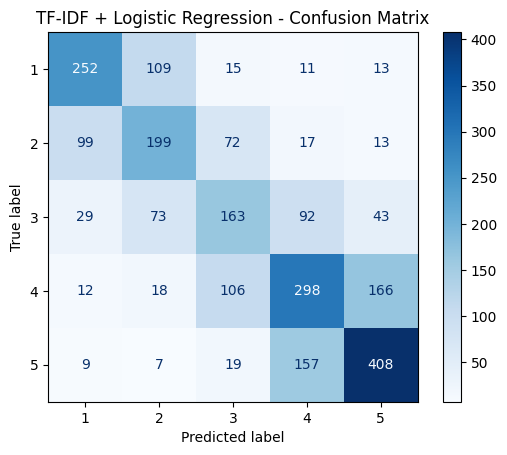

In [19]:
#Baseline Traditional Model: TF-IDF + Logistic Regression

start = time.time()

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
log_reg.fit(X_train_tfidf, y_train)
y_pred_lr = log_reg.predict(X_test_tfidf)

lr_time = time.time() - start

acc = accuracy_score(y_test, y_pred_lr)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_lr, average='macro', zero_division=0)
mae = mean_absolute_error(y_test + 1, y_pred_lr + 1)
within_one = np.mean(np.abs((y_test + 1) - (y_pred_lr + 1)) <= 1)

results.append({
    'Model': 'TF-IDF + Logistic Regression',
    'Accuracy': acc,
    'Precision_macro': precision,
    'Recall_macro': recall,
    'F1_macro': f1,
    'MAE_rating': mae,
    'Within_1_rating_accuracy': within_one,
    'Training_time_seconds': lr_time
})
prediction_store['TF-IDF + Logistic Regression'] = y_pred_lr

print('TF-IDF + Logistic Regression time:', round(lr_time, 2), 'seconds')
print(classification_report(y_test + 1, y_pred_lr + 1, zero_division=0))

cm = confusion_matrix(y_test + 1, y_pred_lr + 1, labels=[1, 2, 3, 4, 5])
ConfusionMatrixDisplay(cm, display_labels=[1, 2, 3, 4, 5]).plot(cmap='Blues', values_format='d')
plt.title('TF-IDF + Logistic Regression - Confusion Matrix')
plt.show()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 190, 128)          2560000   
                                                                 
 simple_rnn (SimpleRNN)      (None, 64)                12352     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense (Dense)               (None, 64)                4160      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 5)                 325       
                                                                 
Total params: 2,576,837
Trainable params: 2,576,837
Non-

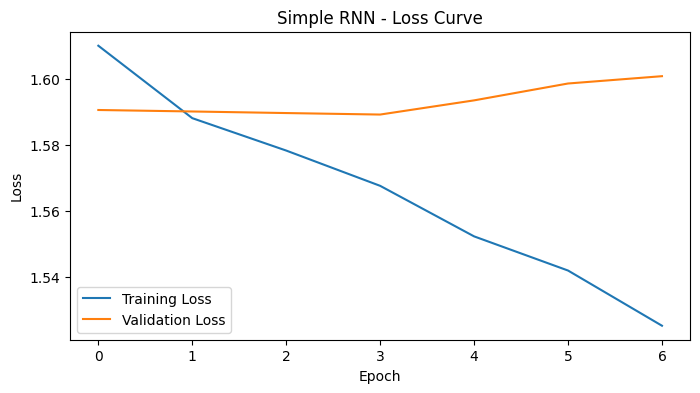

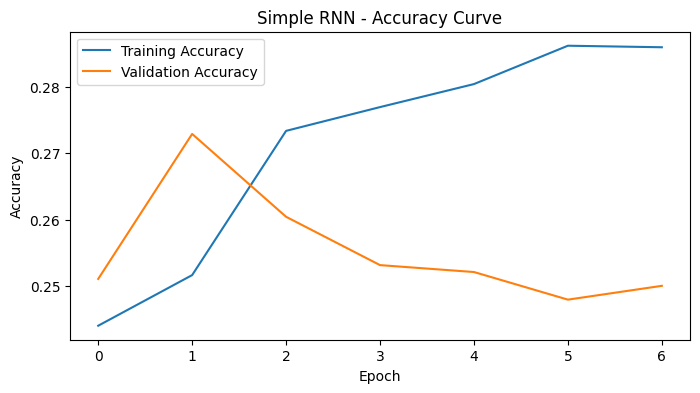

Simple RNN Evaluation
Exact Accuracy: 0.2462
Within ±1 Rating Accuracy: 0.6
MAE Rating Error: 1.4725
Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       400
           2       0.00      0.00      0.00       400
           3       0.00      0.00      0.00       400
           4       0.25      0.58      0.35       600
           5       0.24      0.41      0.30       600

    accuracy                           0.25      2400
   macro avg       0.10      0.20      0.13      2400
weighted avg       0.12      0.25      0.16      2400



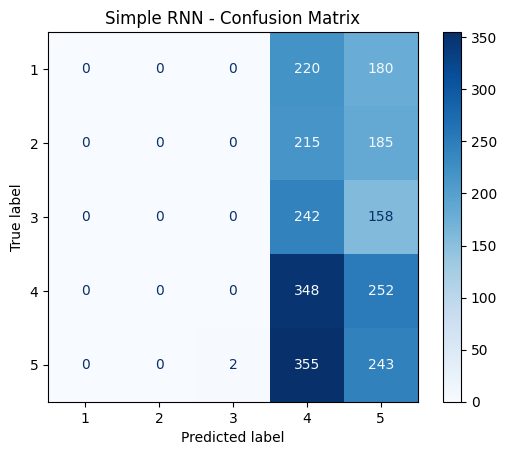

In [20]:
#Model 1: Simple RNN with Trainable Embedding Layer

EMBEDDING_DIM = 128

rnn_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SimpleRNN(64),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

rnn_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model, history_rnn = train_model(rnn_model, 'Simple RNN')

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 190, 128)          2560000   
                                                                 
 bidirectional (Bidirectiona  (None, 128)              98816     
 l)                                                              
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_3 (Dense)             (None, 5)                 325       
                                                      

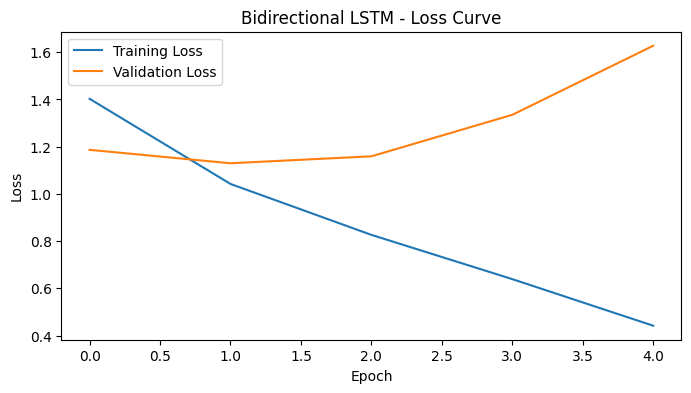

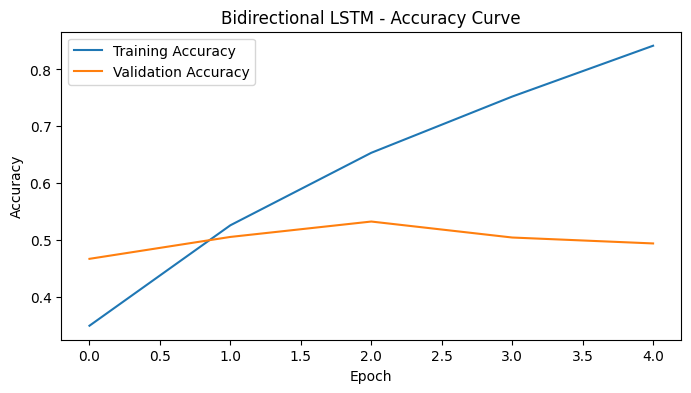

Bidirectional LSTM Evaluation
Exact Accuracy: 0.5062
Within ±1 Rating Accuracy: 0.8871
MAE Rating Error: 0.6479
Classification Report:
              precision    recall  f1-score   support

           1       0.53      0.74      0.62       400
           2       0.38      0.30      0.33       400
           3       0.41      0.30      0.35       400
           4       0.49      0.47      0.48       600
           5       0.61      0.66      0.63       600

    accuracy                           0.51      2400
   macro avg       0.48      0.49      0.48      2400
weighted avg       0.49      0.51      0.49      2400



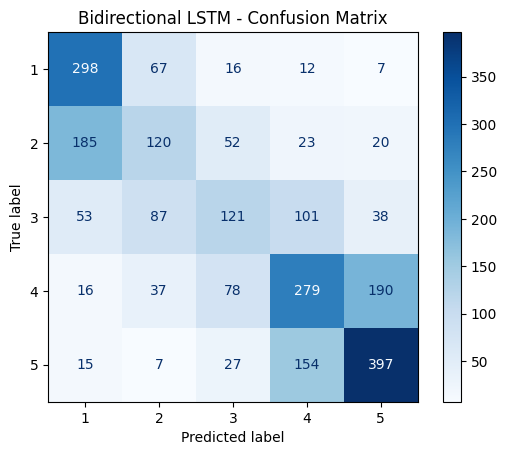

In [21]:
#Model 2: LSTM with Trainable Embedding Layer

lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

lstm_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model, history_lstm = train_model(lstm_model, 'Bidirectional LSTM')

In [22]:
#Model 3: LSTM with Pretrained Word2Vec/GloVe Embeddings

EMBEDDING_DIM_W2V = 50
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM_W2V))
embedding_source = None

try:
    import gensim.downloader as api
    print('Loading pretrained GloVe embeddings.')
    embedding_model = api.load('glove-wiki-gigaword-50')
    embedding_source = 'Pretrained GloVe: glove-wiki-gigaword-50'

    for word, i in tokenizer.word_index.items():
        if i >= vocab_size:
            continue
        if word in embedding_model:
            embedding_matrix[i] = embedding_model[word]

except Exception as e:
    print('Could not load pretrained embeddings:', e)
    print('Falling back to training Word2Vec on this dataset.')
    from gensim.models import Word2Vec

    tokenized_reviews = [text.split() for text in X_train]
    embedding_model = Word2Vec(
        sentences=tokenized_reviews,
        vector_size=EMBEDDING_DIM_W2V,
        window=5,
        min_count=2,
        workers=4,
        seed=SEED
    )
    embedding_source = 'Dataset-trained Word2Vec fallback'

    for word, i in tokenizer.word_index.items():
        if i >= vocab_size:
            continue
        if word in embedding_model.wv:
            embedding_matrix[i] = embedding_model.wv[word]

nonzero = np.count_nonzero(np.sum(embedding_matrix, axis=1))
coverage = nonzero / vocab_size
print('Embedding source:', embedding_source)
print('Embedding coverage:', round(coverage * 100, 2), '%')

Loading pretrained GloVe embeddings.
Embedding source: Pretrained GloVe: glove-wiki-gigaword-50
Embedding coverage: 89.18 %


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 190, 50)           1000000   
                                                                 
 bidirectional_1 (Bidirectio  (None, 128)              58880     
 nal)                                                            
                                                                 
 dropout_4 (Dropout)         (None, 128)               0         
                                                                 
 dense_4 (Dense)             (None, 64)                8256      
                                                                 
 dropout_5 (Dropout)         (None, 64)                0         
                                                                 
 dense_5 (Dense)             (None, 5)                 325       
                                                      

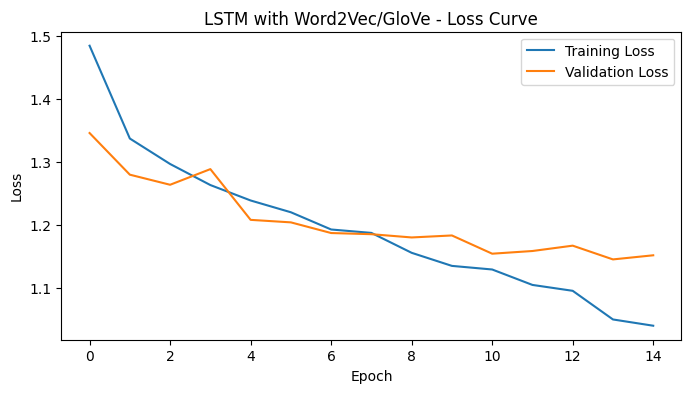

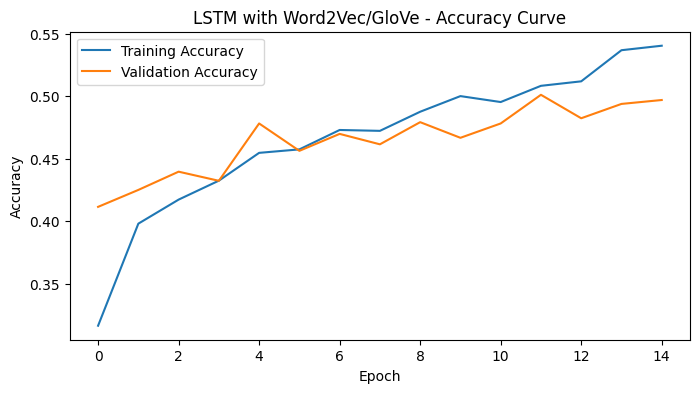

LSTM with Word2Vec/GloVe Evaluation
Exact Accuracy: 0.4929
Within ±1 Rating Accuracy: 0.8829
MAE Rating Error: 0.6871
Classification Report:
              precision    recall  f1-score   support

           1       0.55      0.70      0.62       400
           2       0.39      0.39      0.39       400
           3       0.41      0.22      0.28       400
           4       0.46      0.48      0.47       600
           5       0.57      0.62      0.59       600

    accuracy                           0.49      2400
   macro avg       0.48      0.48      0.47      2400
weighted avg       0.48      0.49      0.48      2400



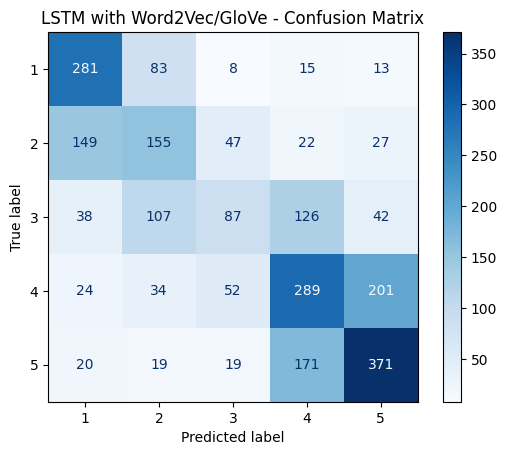

In [23]:
w2v_lstm_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM_W2V,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False
    ),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

w2v_lstm_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

w2v_lstm_model, history_w2v = train_model(w2v_lstm_model, 'LSTM with Word2Vec/GloVe')

In [24]:
#Final Model Comparison

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1_macro', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,MAE_rating,Within_1_rating_accuracy,Training_time_seconds
0,TF-IDF + Logistic Regression,0.550000,0.541206,0.542333,0.541473,0.572083,0.914167,3.309277
1,Bidirectional LSTM,0.506250,0.482745,0.494833,0.482164,0.647917,0.887083,44.900577
2,LSTM with Word2Vec/GloVe,0.492917,0.475578,0.481500,0.470573,0.687083,0.882917,117.661402
3,Simple RNN,0.246250,0.098175,0.197000,0.130377,1.472500,0.600000,240.087468


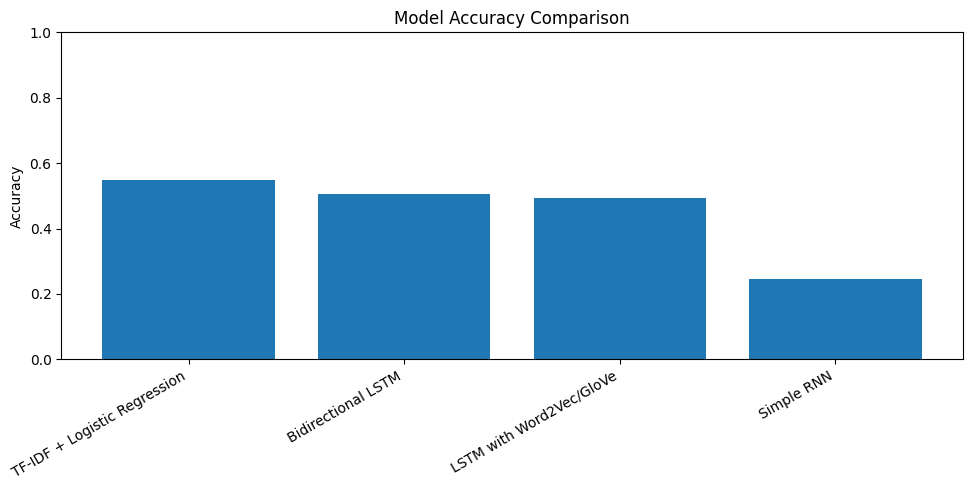

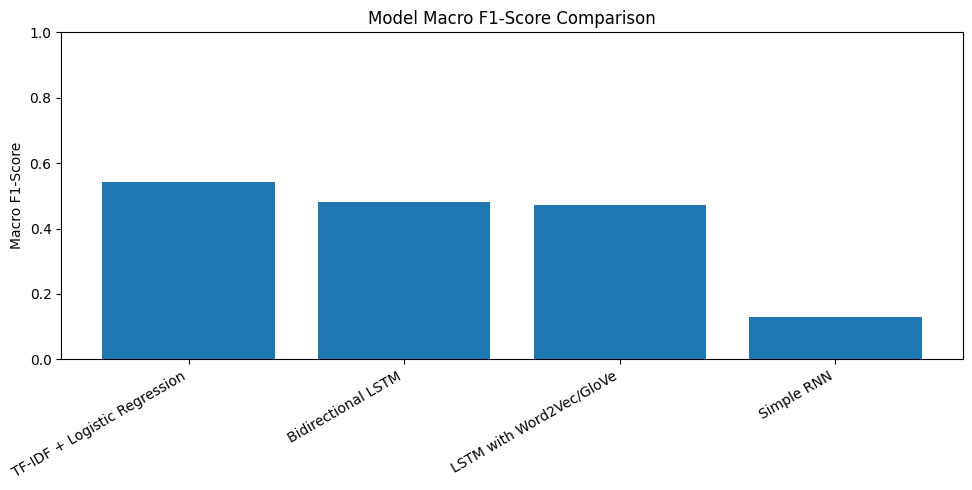

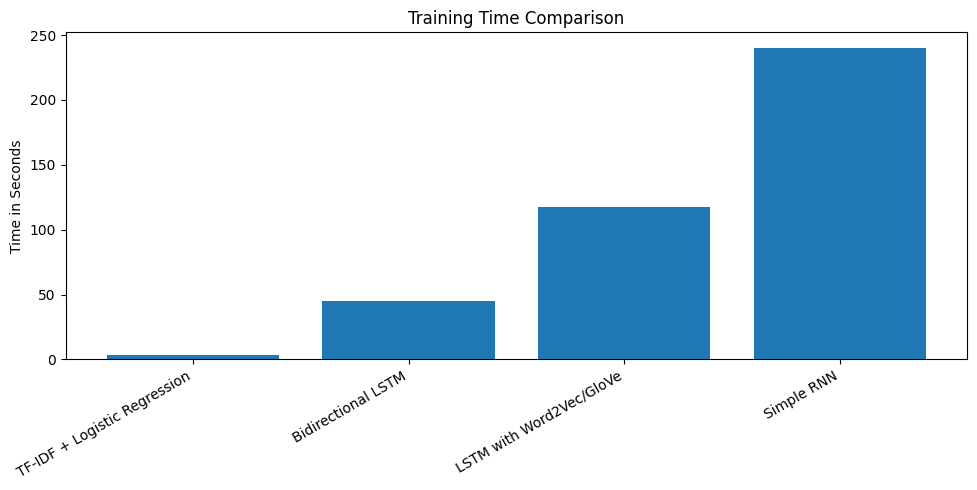

In [25]:
plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['F1_macro'])
plt.title('Model Macro F1-Score Comparison')
plt.ylabel('Macro F1-Score')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['Training_time_seconds'])
plt.title('Training Time Comparison')
plt.ylabel('Time in Seconds')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [26]:
#Error Analysis: Misclassified Examples

best_model_name = results_df.iloc[0]['Model']
y_pred_best = prediction_store[best_model_name]

print('Best model based on Macro F1:', best_model_name)

error_indices = np.where(y_pred_best != y_test)[0]
print('Total misclassified test examples:', len(error_indices))

# Show 5 incorrect examples
for i, error_idx in enumerate(error_indices[:5], start=1):
    print('='*120)
    print(f'Error Example {i}')
    print('Actual rating:', y_test[error_idx] + 1)
    print('Predicted rating:', y_pred_best[error_idx] + 1)
    print('Review text:')
    print(X_test[error_idx][:1000])

Best model based on Macro F1: TF-IDF + Logistic Regression
Total misclassified test examples: 1080
Error Example 1
Actual rating: 2
Predicted rating: 5
Review text:
frustrating read book potential great read however torture indecision character make want pull hair story could half long without cannot stuff wont reading second book
Error Example 2
Actual rating: 4
Predicted rating: 5
Review text:
decent romantic suspense time got bit wordy concept story good jolene benate u deputy marshal worked hard get man warrent squad wont let anything jeopardize spot team jolene wasnt anyways tough deputy marshal six year ago sweet nieve year old thought found man dream married less year later widow hard tried hasnt able anyone else since attempt made life shot marshal put protective custody elite army team take secret army base everything thought knew husband happened lie turn husband isnt dead paul benate one freakinly smart men work soley goverment top secret project knew year ago no business ge

In [27]:
results_df.to_csv('part3_book_review_model_results.csv', index=False)

In [28]:
def gradio_predict(review):
    try:
        if review is None or review.strip() == "":
            return "Please enter a review."

        cleaned_review = clean_text(review)
        review_tfidf = tfidf.transform([cleaned_review])
        prediction = log_reg.predict(review_tfidf)[0]

        rating = int(prediction) + 1

        if rating == 1:
            return "1 Star"
        else:
            return f"{rating} Stars"

    except Exception as e:
        return f"Error: {str(e)}"

In [29]:
custom_css = """
.gradio-container {
    background: #f8fafc !important;
    font-family: Arial, sans-serif !important;
}

#title {
    text-align: center;
    font-size: 34px;
    font-weight: 800;
    color: #111827;
    margin-bottom: 8px;
}

#subtitle {
    text-align: center;
    font-size: 16px;
    color: #475569;
    margin-bottom: 25px;
}

.card {
    background: white;
    border: 1px solid #e5e7eb;
    border-radius: 18px;
    padding: 22px;
    box-shadow: 0 6px 18px rgba(0,0,0,0.06);
}

textarea {
    background: white !important;
    color: #111827 !important;
    border: 1px solid #cbd5e1 !important;
    border-radius: 14px !important;
    font-size: 16px !important;
}

input {
    background: white !important;
    color: #111827 !important;
    border-radius: 14px !important;
    font-size: 20px !important;
    font-weight: 700 !important;
}

.gr-button {
    background: #2563eb !important;
    color: white !important;
    border-radius: 14px !important;
    font-size: 16px !important;
    font-weight: 700 !important;
    border: none !important;
}

.gr-button:hover {
    background: #1d4ed8 !important;
}
"""

In [ ]:
with gr.Blocks(css=custom_css, theme=gr.themes.Default()) as demo:
    gr.HTML("<div id='title'>📚 Book Review Rating Predictor</div>")
    gr.HTML("<div id='subtitle'>Predict book review ratings using TF-IDF and Logistic Regression</div>")

    with gr.Row():
        with gr.Column():
            review_input = gr.Textbox(
                label="Book Review",
                lines=8,
                placeholder="Example: Amazing book. Loved it from beginning to end!"
            )
            predict_button = gr.Button("Predict Rating")

        with gr.Column():
            rating_output = gr.Textbox(
                label="Predicted Rating",
                interactive=False
            )

    predict_button.click(
        fn=gradio_predict,
        inputs=review_input,
        outputs=rating_output
    )

demo.launch(debug=True, share=True)

Running on local URL:  http://127.0.0.1:7860
Running on public URL: https://6b9736cbda0c173047.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)
